In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
# from scipy.sparse import csr_matrix
# from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [16]:

# CSV mit Semikolon laden (deutsches Format)
data = pd.read_csv("Ein_Ausgaben_privat.csv", sep=";")

# Beträge bereinigen: Leerzeichen, €, Punkt (Tausendertrennzeichen), Komma (Dezimal)
def parse_amount(s):
    if pd.isna(s):
        return None
    s = str(s).strip().replace("€", "").replace(".", "").replace(",", ".").strip()
    try:
        return float(s)
    except ValueError:
        print("Error")
        return None

data["amount_parsed"] = data["amount"].apply(parse_amount)
data.head()


,bookingDate,payee,purpose,amount,categoryMain,amount_parsed
0,30.12.25,Philipp Hardy,Kompensationszahlung gemäß Abschlussvereinbarung,"2.000,00 €",ES,2000.00
1,30.12.25,PayPal Europe S.a.r.l. et Cie S.C.A ...,"1047237348812/PP.6580.PP/. , Ihr Einkauf bei","-55,00 €",V,-55.00
2,30.12.25,Vodafone GmbH Ferdinand-Braun-Platz 1,Kd.Nr. 001963060871 VK 1057505887 Rg.Nr. 00377...,"-19,99 €",F,-19.99
3,29.12.25,StratoDE/Berlin,VISA Debitkartenumsatz,"-6,00 €",F,-6.00
4,29.12.25,StratoDE/Berlin,VISA Debitkartenumsatz,"-6,00 €",F,-6.00


In [17]:
print(data["amount_parsed"].shape)
print(data["categoryMain"].shape)

(765,)
(765,)


In [18]:

data["amount_parsed"] = data["amount"].apply(parse_amount)
data["text"] = data["payee"].fillna("") + " " + data["purpose"].fillna("")
data = data.dropna(subset=["categoryMain", "amount_parsed"])

# class_mapping = {
#     'AB': 'A',
#     'AR': 'A',
#     'AT': 'A',
#     'ES': 'E',
#     'FM': 'F',
#     'MF': 'M',
#     'MW': 'M'
# }

# Auf die Zielspalte anwenden (angenommen sie heißt 'category')
# data['categoryMain'] = data['categoryMain'].replace(class_mapping)

In [19]:
print(data.shape)

(765, 7)


In [20]:
# Feature Engineering
data["date"] = pd.to_datetime(data["bookingDate"], format="%d.%m.%y", errors="coerce")
data = data.dropna(subset=["date"])

data["day_of_month"] = data["date"].dt.day
# Wochentag (0=Mo, 6=So)
data["weekday"] = data["date"].dt.weekday
# Ist-Gutschrift: 1 wenn Betrag positiv, sonst 0
data["is_credit"] = (data["amount_parsed"] > 0).astype(int)
# Betrag: Log(|Betrag|+1) um Ausreißer zu dämpfen, Vorzeichen bleibt über is_credit
data["log_amount"] = np.log1p(np.abs(data["amount_parsed"]))


data["amount_bin"] = pd.cut(
     data["amount_parsed"],
     bins=[-np.inf, -500, -50, -10, 0, 10, 50, 500, np.inf],
     labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float).fillna(0)
print(data["text"].shape)

(765,)


In [21]:
import re

def financial_cleaner(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Alles klein schreiben
    text = text.lower()

    # 2. VISA/Mastercard-spezifische Muster entfernen
    # Entfernt "nr xxxx 1234" (Kreditkartennummern-Fragmente)
    text = re.sub(r'nr\s+x+\s+\d+', ' ', text)
    
    # 3. Alphanumerischen Müll (ARN, IDs, Codes mit Mix aus Buchstabe/Zahl) entfernen
    # Erkennt: ARN743960..., 150954 (wenn es Teil einer ID ist)
    text = re.sub(r'\w*\d\w*', ' ', text)

    # 4. Standort-Kürzel am Ende (z.B. "limburg de") säubern
    # Wir behalten Städtenamen, aber entfernen isolierte Länderkürzel wie " de "
    text = re.sub(r'\b(de|at|ch|lu)\b', ' ', text)

    # 5. Begriffe wie "kaufumsatz" oder "entgelt" sind oft in jeder Zeile -> Stoppwörter
    stop_words = ['kaufumsatz', 'visa', 'mastercard', 'kauf', 'umsatz', 'datum', 'KAUFUMSATZ', 'VISA Debitkartenumsatz']
    for word in stop_words:
        text = text.replace(word, ' ')

    # 6. Nur Buchstaben behalten & Leerzeichen fixen
    text = re.sub(r'[^a-zäöüß ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test mit deinem Beispiel:
data['text'] = data['text'].apply(financial_cleaner)

In [22]:
data["text"].to_csv("data_clean_text.csv")

In [23]:
y = data["categoryMain"]

X_text_raw_train, X_text_raw_test, y_train, y_test = train_test_split(
    data["text"], y, test_size=0.2, random_state=42
)
train_idx = X_text_raw_train.index
test_idx  = X_text_raw_test.index

num_cols = ["day_of_month", "weekday", "amount_bin", "is_credit", "amount_parsed"]
numeric_train = data.loc[train_idx, num_cols].values.astype(float)
numeric_test  = data.loc[test_idx, num_cols].values.astype(float)

print(X_text_raw_train.shape)
print(y_train.shape)
print(y_test.shape)

(612,)
(612,)
(153,)


In [24]:
# Sentence-Transformer (Deutsch, 768d mit mpnet) statt TF-IDF
# vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
# X_text_train = vectorizer.fit_transform(X_text_raw_train)
# X_text_test  = vectorizer.transform(X_text_raw_test)
# Embedding-Modell (nur eines aktiv lassen)
# Klassisch: MiniLM 384d, mpnet 768d, e5-large 1024d
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # kleiner, 384d
# model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
# model = SentenceTransformer("intfloat/multilingual-e5-large")
# Qwen3-Embedding (multilingual, 32K Kontext): 0.6B klein, 4B/8B stärker
#model = SentenceTransformer("Qwen/Qwen3-Embedding-4B")  # 1024d; alternativ: Qwen3-Embedding-4B (2560d), 8B (4096d)

# texts = data["text"].tolist()
# texts_with_prefix = [f"passage: {t}" for t in texts]
# X_text_emb = model.encode(texts_with_prefix)


X_text_emb = model.encode(data["text"].tolist())

train_pos = data.index.get_indexer(train_idx)
test_pos = data.index.get_indexer(test_idx)
X_text_train = X_text_emb[train_pos]
X_text_test = X_text_emb[test_pos]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9971.41it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
scaler = StandardScaler()
numeric_train_scaled = scaler.fit_transform(numeric_train)
numeric_test_scaled  = scaler.transform(numeric_test)


In [26]:
# Dense: Text-Embeddings (768d) + numerische Features
# X_train = hstack([X_text_train, csr_matrix(numeric_train_scaled)], format="csr")
# X_test  = hstack([X_text_test,  csr_matrix(numeric_test_scaled)],  format="csr")
X_train = np.hstack([X_text_train, numeric_train_scaled])
X_test = np.hstack([X_text_test, numeric_test_scaled])


In [27]:
clf = LinearSVC(max_iter=5000, random_state=42, dual="auto")
#clf = LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs")

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          AB       0.00      0.00      0.00         2
          AR       0.00      0.00      0.00         2
          AT       0.83      1.00      0.91         5
         AUS       1.00      0.90      0.95        20
           E       0.90      0.84      0.87        31
          ES       1.00      1.00      1.00         3
           F       0.89      0.91      0.90        35
           G       1.00      1.00      1.00         3
           M       0.33      0.40      0.36         5
          MW       0.50      0.33      0.40         3
           U       0.50      0.25      0.33         4
           V       0.68      0.80      0.74        40

    accuracy                           0.80       153
   macro avg       0.64      0.62      0.62       153
weighted avg       0.79      0.80      0.80       153



/Users/philipphardy/Documents/Github/venera/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/philipphardy/Documents/Github/venera/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/philipphardy/Documents/Github/venera/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

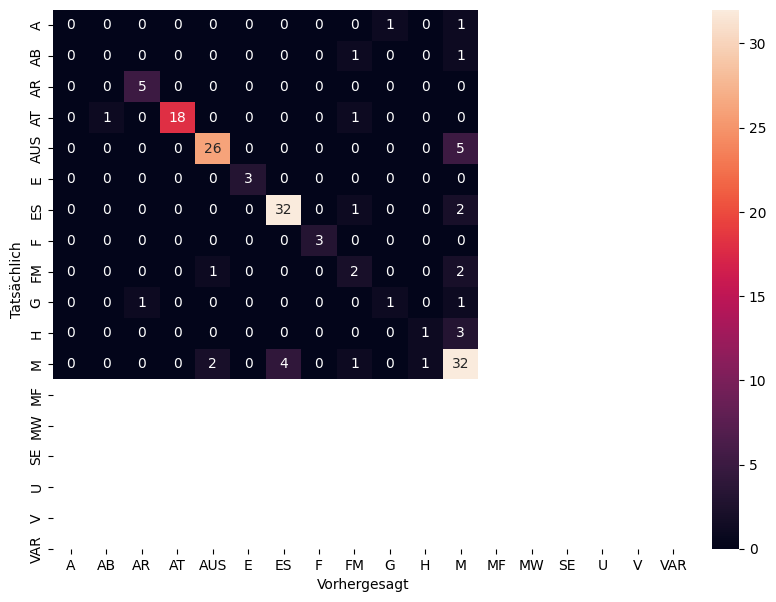

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.show()